## Naseem Saleh
## INST414
## Final Project Assignment¶
## December 15, 2025

dataset source:
https://www.kaggle.com/datasets/rabieelkharoua/predict-pet-adoption-status-dataset/data

Rabie El Kharoua. (2024). Predict Pet Adoption Status Dataset [Data set]. Kaggle. https://doi.org/10.34740/KAGGLE/DS/5242440

https://catalog.data.gov/dataset/austin-animal-center-outcomes-b49ae

Question - How can we use data anlysis to find cats less likely to be adopted / more likely to spend more time in shelter, and which cats are these?

health outcome  ifturnoutimportnt - it's important that shelters record more data such as (temperament or) health conditions in order to have an effective dataset for analysis and an adoption or time at shelter likelihood prediction.

size ,  color 
previous owner



Features:
PetID: Unique identifier for each pet.
PetType: Type of pet (e.g., Dog, Cat, Bird, Rabbit).
Breed: Specific breed of the pet.
AgeMonths: Age of the pet in months.
Color: Color of the pet.
Size: Size category of the pet (Small, Medium, Large).
WeightKg: Weight of the pet in kilograms.
Vaccinated: Vaccination status of the pet (0 - Not vaccinated, 1 - Vaccinated).
HealthCondition: Health condition of the pet (0 - Healthy, 1 - Medical condition).
TimeInShelterDays: Duration the pet has been in the shelter (days).
AdoptionFee: Adoption fee charged for the pet (in dollars).
PreviousOwner: Whether the pet had a previous owner (0 - No, 1 - Yes).
AdoptionLikelihood: Likelihood of the pet being adopted (0 - Unlikely, 1 - Likely).
 / Not adopted vs adopted

In [1]:
#from sklearn.metrics import DistanceMetric, pairwise_distances

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import MultiLabelBinarizer

import matplotlib.pyplot as plt

In [3]:
#Loading the csv into a dataframe
pets_df = pd.read_csv("pet_adoption_data.csv")
print("Pet Adoption Data Rows", len(pets_df))

Pet Adoption Data Rows 2007


In [4]:
pets_df.head()

,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood
0,500,Bird,Parakeet,131,Orange,Large,5.039768,1,0,27,140,0,0
1,501,Rabbit,Rabbit,73,White,Large,16.086727,0,0,8,235,0,0
2,502,Dog,Golden Retriever,136,Orange,Medium,2.076286,0,0,85,385,0,0
3,503,Bird,Parakeet,97,White,Small,3.339423,0,0,61,217,1,0
4,504,Rabbit,Rabbit,123,Gray,Large,20.498100,0,0,28,14,1,0


In [5]:
pets_df["PetType"].unique()

array(['Bird', 'Rabbit', 'Dog', 'Cat'], dtype=object)

### Data Cleaning / Checking

In [6]:
#Filtering, getting only the cats data:
cat_df = pets_df[pets_df["PetType"] == "Cat"].copy()

In [7]:
#Checking it worked:
cat_df.head()

,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood
7,507,Cat,Siamese,13,Orange,Large,7.252683,1,0,3,137,0,1
13,513,Cat,Siamese,27,Black,Large,28.285412,1,0,5,135,0,0
14,514,Cat,Persian,160,Brown,Medium,6.303899,1,0,11,404,0,1
16,516,Cat,Persian,8,Orange,Small,11.933224,1,1,64,405,1,0
17,517,Cat,Persian,50,White,Medium,28.982929,1,0,13,109,0,1


In [8]:
#cat_df = cat_df.reindex(sorted(cat_df.columns), axis = 1)

In [9]:
cat_df["Color"].unique()

array(['Orange', 'Black', 'Brown', 'White', 'Gray'], dtype=object)

In [10]:
cat_df["Color"].value_counts()

Color
Black     114
Orange    108
White     100
Brown      97
Gray       86
Name: count, dtype: int64

In [11]:
cat_df["Size"].value_counts()

Size
Medium    184
Small     161
Large     160
Name: count, dtype: int64

In [12]:
cat_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 505 entries, 7 to 2000
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PetID               505 non-null    int64  
 1   PetType             505 non-null    object 
 2   Breed               505 non-null    object 
 3   AgeMonths           505 non-null    int64  
 4   Color               505 non-null    object 
 5   Size                505 non-null    object 
 6   WeightKg            505 non-null    float64
 7   Vaccinated          505 non-null    int64  
 8   HealthCondition     505 non-null    int64  
 9   TimeInShelterDays   505 non-null    int64  
 10  AdoptionFee         505 non-null    int64  
 11  PreviousOwner       505 non-null    int64  
 12  AdoptionLikelihood  505 non-null    int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 55.2+ KB


In [13]:
cat_df["PreviousOwner"].value_counts()

PreviousOwner
0    341
1    164
Name: count, dtype: int64

In [14]:
cat_df["AdoptionLikelihood"].value_counts()

AdoptionLikelihood
0    360
1    145
Name: count, dtype: int64

In [15]:
# 0 means no health condition
cat_df["HealthCondition"].value_counts()

HealthCondition
0    394
1    111
Name: count, dtype: int64

In [16]:
# 0 mean no , 1 mean vaccinated
cat_df["Vaccinated"].value_counts()

Vaccinated
1    352
0    153
Name: count, dtype: int64

In [17]:
#Checking for nulls
cat_df.isnull().sum()

PetID                 0
PetType               0
Breed                 0
AgeMonths             0
Color                 0
Size                  0
WeightKg              0
Vaccinated            0
HealthCondition       0
TimeInShelterDays     0
AdoptionFee           0
PreviousOwner         0
AdoptionLikelihood    0
dtype: int64

In [18]:
cat_df["Breed"].value_counts()

Breed
Siamese    253
Persian    252
Name: count, dtype: int64

In [19]:
cat_df["PetType"].value_counts()

PetType
Cat    505
Name: count, dtype: int64

In [20]:
cat_df.head()

,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood
7,507,Cat,Siamese,13,Orange,Large,7.252683,1,0,3,137,0,1
13,513,Cat,Siamese,27,Black,Large,28.285412,1,0,5,135,0,0
14,514,Cat,Persian,160,Brown,Medium,6.303899,1,0,11,404,0,1
16,516,Cat,Persian,8,Orange,Small,11.933224,1,1,64,405,1,0
17,517,Cat,Persian,50,White,Medium,28.982929,1,0,13,109,0,1


### Preprocessing or cleaning r changing Before clustering

In [21]:

#Dropping outcome columns to see if clustering can get differences
cat_df_features = cat_df.drop(columns=["AdoptionLikelihood", "TimeInShelterDays", "PetType", "PetID", "AdoptionFee"])


In [22]:
cat_df_features.head()

,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,PreviousOwner
7,Siamese,13,Orange,Large,7.252683,1,0,0
13,Siamese,27,Black,Large,28.285412,1,0,0
14,Persian,160,Brown,Medium,6.303899,1,0,0
16,Persian,8,Orange,Small,11.933224,1,1,1
17,Persian,50,White,Medium,28.982929,1,0,0


In [23]:
#cat_df_features["AdoptionFee"].unique()

In [24]:
np.histogram(cat_df_features["AgeMonths"])

(array([59, 40, 48, 56, 53, 40, 51, 50, 46, 62]),
 array([  2. ,  19.7,  37.4,  55.1,  72.8,  90.5, 108.2, 125.9, 143.6,
        161.3, 179. ]))

In [25]:
cat_df_features["WeightKg"].unique()

array([ 7.25268319, 28.28541176,  6.30389854, 11.93322365, 28.98292944,
       16.55764134,  2.43586626, 21.6974815 , 20.35262364,  3.4299382 ,
       23.1134871 , 20.40870808,  8.55957957,  1.01819798, 28.9297298 ,
       27.60880194, 23.17247965, 13.9775838 ,  1.46168775, 18.86930599,
       28.8640531 ,  8.95075709, 13.1186359 ,  2.60755668, 27.3420691 ,
       29.37159342,  5.94560342,  7.10333049, 26.44198235, 20.49849388,
        7.88924042,  6.32335931, 24.80665719,  9.17212316,  4.58703467,
       10.32445726, 27.52614225,  2.10342617, 12.11824805,  4.33951783,
       26.52448725, 19.51215189, 21.28215749, 25.63446847, 16.45256684,
       22.93963585,  3.76221909, 29.81376701,  6.02848592, 15.31091994,
        1.45970342,  9.7760723 , 26.58986641,  3.60484175,  6.77132754,
        1.06334014, 28.69683243,  1.03677423, 16.12964224,  8.77033975,
       11.48661223, 24.47171679,  6.11675334, 28.721192  ,  3.04175551,
       12.12940128,  6.43828946,  1.30599747,  3.6513618 , 17.14

In [26]:
cat_df_features["WeightKg"].value_counts()

WeightKg
8.576109     1
7.252683     1
28.285412    1
6.303899     1
11.933224    1
            ..
1.018198     1
8.559580     1
20.408708    1
23.113487    1
3.429938     1
Name: count, Length: 505, dtype: int64

In [27]:
#Dropping weight since might be contradictory to size, 
# though it may consider the average idea of size for the age of the cat and decide if it's larger or smaller than normal
cat_df_features2 = cat_df_features.drop(columns=["WeightKg"])
cat_df_features2.head()

,Breed,AgeMonths,Color,Size,Vaccinated,HealthCondition,PreviousOwner
7,Siamese,13,Orange,Large,1,0,0
13,Siamese,27,Black,Large,1,0,0
14,Persian,160,Brown,Medium,1,0,0
16,Persian,8,Orange,Small,1,1,1
17,Persian,50,White,Medium,1,0,0


In [28]:
#Scaling age for use in clustering since there are many variations
from sklearn.preprocessing import StandardScaler

cat_df_features2["AgeMonths"] = StandardScaler().fit_transform(cat_df_features2[["AgeMonths"]])

In [29]:
cat_df_features2.head()

,Breed,AgeMonths,Color,Size,Vaccinated,HealthCondition,PreviousOwner
7,Siamese,-1.493672,Orange,Large,1,0,0
13,Siamese,-1.226864,Black,Large,1,0,0
14,Persian,1.307812,Brown,Medium,1,0,0
16,Persian,-1.588960,Orange,Small,1,1,1
17,Persian,-0.788536,White,Medium,1,0,0


In [30]:
#Changing age from months to years
#cat_df_features2["AgeYears"] = np.floor(cat_df_features2["AgeMonths"] / 12)
#Print to check:
#cat_df_features2.head()

In [31]:
#cat_df_features2["AgeYears"].value_counts()


In [32]:
#cat_df_features2.head()

In [33]:
#cat_df_features2["AgeYears"] = cat_df_features2["AgeYears"].replace({
#    14.0 : "Older", 13.0 : "Older", 12.0 : "Older", 11.0 : "Older", 
#    10.0 : "Adult", 9.0 : "Adult", 8.0 : "Adult", 7.0 : "Adult", 6.0 : "Young Adult", 5.0 : "Young Adult", 4.0 : "Young Adult",
#    3.0 : "Young Adult", 2.0 : "Young Adult", 1.0 : "Kitten", 0.0 : "Kitten"
#})

# or 6 young adult, 0.0 1 or 2 kitten

# Group 2 1 and 0  juvenile  for ml ?


In [34]:
#cat_df_features2.head()

In [35]:
#Changing adoption fee to round
#cat_df_features2["AdoptionFee_Rounded"] = (cat_df_features2["AdoptionFee"]).round(-2)
#Print to check:
#cat_df_features2.head()

In [36]:
#cat_df_features2["AdoptionFee_Rounded"].value_counts()

In [37]:
#cat_df_features2["AdoptionFee_Rounded"] = cat_df_features2["AdoptionFee_Rounded"].replace({
#    500 : "Near 500", 400 : "Near 400", 300 : "Near 300", 200 : "Near 200", 100 : "Near 100", 0 : "Less than 100"
#})

In [38]:
#cat_df_features2["AdoptionFee_Rounded"].value_counts()

In [39]:
#cat_df_features2 = cat_df_features2.drop(columns=["WeightKg"], errors = "ignore")
#cat_df_features2.head()

In [40]:
#Binarizing color and breed
cat_df_features2 = pd.get_dummies(cat_df_features2, columns = ["Color", "Breed"])


In [41]:
cat_df_features2.head()

,AgeMonths,Size,Vaccinated,HealthCondition,PreviousOwner,Color_Black,Color_Brown,Color_Gray,Color_Orange,Color_White,Breed_Persian,Breed_Siamese
7,-1.493672,Large,1,0,0,False,False,False,True,False,False,True
13,-1.226864,Large,1,0,0,True,False,False,False,False,False,True
14,1.307812,Medium,1,0,0,False,True,False,False,False,True,False
16,-1.588960,Small,1,1,1,False,False,False,True,False,True,False
17,-0.788536,Medium,1,0,0,False,False,False,False,True,True,False


In [42]:
#cat_features_binary2.head()

In [43]:
from sklearn.preprocessing import OrdinalEncoder

#Encoding Size category
#Category making sure numerically correct
ord_encoder = OrdinalEncoder(categories = [["Small", "Medium", "Large"]])
#Putting back into the dataframe
cat_df_features2["Size"] = ord_encoder.fit_transform(cat_df_features2[["Size"]])

In [44]:
#cat_features_binary2 = cat_features_binary2.drop(columns=["AdoptionFee", "AgeMonths"], errors = "ignore")
#cat_features_binary2.head()

In [45]:
#cat_features_binary2 = pd.get_dummies(cat_df_features2[string_cols], prefix = string_cols)

In [46]:
#cat_features_binary = pd.get_dummies(cat_df_features[string_cols], prefix = string_cols)

In [47]:
#cat_features_binary2.head()

In [48]:
cat_df_features2.head()

,AgeMonths,Size,Vaccinated,HealthCondition,PreviousOwner,Color_Black,Color_Brown,Color_Gray,Color_Orange,Color_White,Breed_Persian,Breed_Siamese
7,-1.493672,2.0,1,0,0,False,False,False,True,False,False,True
13,-1.226864,2.0,1,0,0,True,False,False,False,False,False,True
14,1.307812,1.0,1,0,0,False,True,False,False,False,True,False
16,-1.588960,0.0,1,1,1,False,False,False,True,False,True,False
17,-0.788536,1.0,1,0,0,False,False,False,False,True,True,False


In [49]:
#cat_features_binary2.drop(columns=["AgeMonths", "Vaccinated", "PreviousOwner", "Cluster", "AdoptionFee", "HealthCondition"], inplace = True, errors = "ignore")

In [50]:
#cat_features_binary2.head()

In [51]:
#cat_features_df2 = pd.concat([cat_df_features2, cat_features_binary2], axis = 1)

In [52]:
#cat_features_df1.drop(columns=["Breed", "Color", "Size"], inplace = True)

In [53]:
#cat_features_df2.drop(columns=["Breed", "Color", "Size", "AgeMonths", "AdoptionFee", "AdoptionFee_Rounded", "AgeYears"], inplace = True, errors = "ignore")

In [54]:
#cat_features_df2.head()

In [55]:
#cat_features_df2.info()

In [56]:
cat_df_features2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 505 entries, 7 to 2000
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   AgeMonths        505 non-null    float64
 1   Size             505 non-null    float64
 2   Vaccinated       505 non-null    int64  
 3   HealthCondition  505 non-null    int64  
 4   PreviousOwner    505 non-null    int64  
 5   Color_Black      505 non-null    bool   
 6   Color_Brown      505 non-null    bool   
 7   Color_Gray       505 non-null    bool   
 8   Color_Orange     505 non-null    bool   
 9   Color_White      505 non-null    bool   
 10  Breed_Persian    505 non-null    bool   
 11  Breed_Siamese    505 non-null    bool   
dtypes: bool(7), float64(2), int64(3)
memory usage: 27.1 KB


In [57]:
cat_features_df2 = cat_df_features2

In [58]:
cat_features_df0 = cat_features_df2.drop(columns = ["Breed_Persian", "Breed_Siamese"])

## Clustering

In [59]:
#Using AgglomerativeClustering to get the clusters . 
from sklearn.cluster import AgglomerativeClustering
clustering = AgglomerativeClustering(n_clusters = 6, metric = "euclidean", linkage = "ward").fit(cat_features_df0)
clustering
#AgglomerativeClustering()
labels = clustering.labels_
#array

In [60]:
cat_df["Cluster"] = labels

In [61]:
inertia_scores=[]

In [62]:

from sklearn.cluster import MiniBatchKMeans

#Fitting a k-means clustering model and recording the ".inertia" parameter of the fitted model

for test_k in range(2,20):
    temp_model = MiniBatchKMeans(n_clusters = test_k, n_init = 16, max_iter = 2048, tol = 0.5, reassignment_ratio = 0.5, random_state = 42)
    temp_model.fit(cat_features_df2)
    #Repeat for k from 2 to 30, recording the ".inertia" value for each k.
    scores = temp_model.inertia_
    inertia_scores.append((test_k, scores))

    #init 16 so run16times to find best cluster center, max iteration 2048,  tolerance val 0.5 so smalechtimer s lessnoise, 42 seedvalue so consistent
    # estimate n_init lk test biggrnumbrifnotgettingaccurateclusters  ,  reasasignmnt_ratio  take 0.5 ofdata getnewpoint s data  sopreventerror andkeeprunning

In [63]:
#Recording the `.inertia_` value for each k.
inertia_df = pd.DataFrame(inertia_scores, columns = ["k", "inertia"])

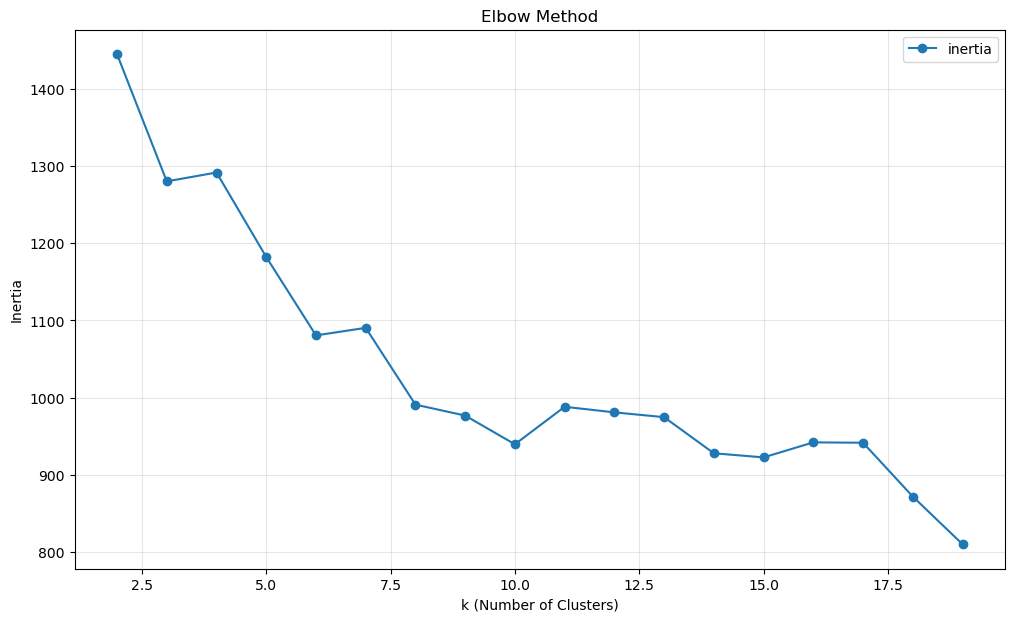

In [64]:
fig = plt.figure(figsize = (12,7))
ax = fig.add_subplot(1,1,1) # ax = axis
inertia_df.sort_values(by = "k").plot("k", "inertia", marker = "o", ax = ax)

ax.set_xlabel("k (Number of Clusters)") #Label x-axis
ax.set_ylabel("Inertia") # Label y-axis
ax.set_title("Elbow Method")
ax.grid(True, alpha= 0.3)
plt.show()

#Plotting the inertia values and using this plot to select a value for k.

In [65]:
#Checking the clusters matched to the adoption outcome in the df
outcome_clusters = pd.DataFrame({"AdoptionLikelihood": cat_df["AdoptionLikelihood"], "Cluster": labels})
print(outcome_clusters.sort_values("Cluster"))

      AdoptionLikelihood  Cluster
16                     0        0
1990                   1        0
78                     0        0
1999                   1        0
1916                   1        0
...                  ...      ...
272                    1        5
230                    1        5
266                    0        5
161                    0        5
1924                   1        5

[505 rows x 2 columns]


In [66]:
#Evaluating adoption outcome likelihood for the clusters of cats
print(outcome_clusters.groupby("Cluster")["AdoptionLikelihood"].value_counts(normalize=True))

print(outcome_clusters["Cluster"].value_counts())

Cluster  AdoptionLikelihood
0        0                     0.620690
         1                     0.379310
1        0                     0.619565
         1                     0.380435
2        0                     0.752294
         1                     0.247706
3        0                     0.852632
         1                     0.147368
4        0                     0.600000
         1                     0.400000
5        0                     0.854167
         1                     0.145833
Name: proportion, dtype: float64
Cluster
0    116
2    109
3     95
1     92
5     48
4     45
Name: count, dtype: int64


In [67]:
from sklearn.metrics import silhouette_score

X = cat_features_df2.values

score = silhouette_score(X, cat_df["Cluster"])
print("Silhouette Score:", score)

Silhouette Score: 0.09873804605973162


In [68]:
#Connecting time spent in shelter to the clusters
outcome_clusters2 = pd.DataFrame({"TimeInShelterDays": cat_df["TimeInShelterDays"], "Cluster": labels})
print(outcome_clusters2.sort_values("Cluster"))

      TimeInShelterDays  Cluster
16                   64        0
1990                  1        0
78                   87        0
1999                 13        0
1916                 18        0
...                 ...      ...
272                  38        5
230                  21        5
266                  16        5
161                  11        5
1924                 68        5

[505 rows x 2 columns]


In [69]:
#Evaluating how long a cluster of cats stays in the shelter on average
print(outcome_clusters2.groupby("Cluster")["TimeInShelterDays"].mean())

print(outcome_clusters2["Cluster"].value_counts())

Cluster
0    39.663793
1    45.891304
2    47.293578
3    40.705263
4    44.755556
5    37.958333
Name: TimeInShelterDays, dtype: float64
Cluster
0    116
2    109
3     95
1     92
5     48
4     45
Name: count, dtype: int64


In [70]:
cat_df.groupby(["Cluster", "Color"])["AdoptionLikelihood"].mean()

Cluster  Color 
0        Black     0.235294
         Brown     0.380952
         Gray      0.447368
         Orange    0.368421
1        Black     0.361702
         Brown     0.307692
         Orange    0.437500
2        Black     0.000000
         Brown     0.315789
         Orange    0.325000
         White     0.250000
3        Black     0.343750
         Brown     0.086957
         Orange    0.000000
         White     0.043478
4        White     0.400000
5        Gray      0.145833
Name: AdoptionLikelihood, dtype: float64

In [71]:
cat_df.groupby(["Cluster", "Size"])["AdoptionLikelihood"].mean()

Cluster  Size  
0        Large     0.500000
         Medium    0.707317
         Small     0.183099
1        Large     0.211538
         Medium    0.631579
         Small     0.000000
2        Medium    0.658537
         Small     0.000000
3        Large     0.057971
         Medium    0.384615
4        Large     0.083333
         Medium    0.761905
         Small     0.083333
5        Large     0.043478
         Medium    0.294118
         Small     0.125000
Name: AdoptionLikelihood, dtype: float64

In [72]:
#Count how many in each cluster there is 
count_clusters = outcome_clusters["Cluster"].value_counts().sort_index()

print(count_clusters)

Cluster
0    116
1     92
2    109
3     95
4     45
5     48
Name: count, dtype: int64


In [73]:
#Seeing some of the h in each cluster
#for c in sorted(cat_df["Cluster"].unique()):
#    sample = outcome_clusters2[cat_df["Cluster"] == c]["Color"].tolist()[:15]
#    print(f"Cluster {c}: {sample} ... \n")

In [74]:
#Changing adoption fee to round
#Changing age from months to years
#cat_df_features2["AgeYears"] = np.floor(cat_df_features2["AgeMonths"] / 12)
#Print to check:
#cat_df_features2.head()

##Rounding the time in shelter to months
#cat_df["TimeInShelterMonths"] = (cat_df["TimeInShelterDays"] / 30).round()
#Print to check:
#cat_df.head()

#cat_df_features2["AgeYears"].value_counts()
#
#cat_df_features2["AgeYears"] = cat_df_features2["AgeYears"].replace({
#    14.0 : "Older", 13.0 : "Older", 12.0 : "Older", 11.0 : "Older", 
#    10.0 : "Adult", 9.0 : "Adult", 8.0 : "Adult", 7.0 : "Adult", 6.0 : "Young Adult", 5.0 : "Young Adult", 4.0 : "Young Adult",
#    3.0 : "Young Adult", 2.0 : "Young Adult", 1.0 : "Kitten", 0.0 : "Kitten"
#})

# or 6 young adult, 0.0 1 or 2 kitten

# Group 2 1 and 0  juvenile  for ml ?

#cat_df_features2["AdoptionFee_Rounded"] = (cat_df_features2["AdoptionFee"]).round(-2)
#Print to check:
#cat_df_features2.head()

#cat_df_features2["AdoptionFee_Rounded"].value_counts()

In [75]:
cat_df.groupby("Cluster")[["Vaccinated", "HealthCondition", "TimeInShelterDays", "AdoptionLikelihood"]].mean()


,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionLikelihood
Cluster,,,,
0,0.715517,0.206897,39.663793,0.379310
1,0.641304,0.195652,45.891304,0.380435
2,0.743119,0.165138,47.293578,0.247706
3,0.663158,0.305263,40.705263,0.147368
4,0.711111,0.222222,44.755556,0.400000
5,0.708333,0.250000,37.958333,0.145833


In [76]:
cat_df.groupby("Cluster")[["AgeMonths", "AdoptionFee"]].mean()

,AgeMonths,AdoptionFee
Cluster,,
0,48.517241,236.163793
1,45.663043,250.228261
2,134.403670,231.605505
3,136.894737,269.989474
4,50.800000,252.711111
5,132.812500,253.875000


In [77]:
#Analyzing the clusters by the categories

#Sum of breed per cluster
print(cat_df.groupby("Cluster")["Breed"].value_counts(normalize=True))
print("\n")
#Sum of color per cluster
print(cat_df.groupby("Cluster")["Color"].value_counts(normalize=True))
print("\n")

#Average age
print(cat_df.groupby("Cluster")["AgeMonths"].mean())
print("\n")

#Average time in shelter per cluster
print(cat_df.groupby("Cluster")["TimeInShelterDays"].mean())
print("\n")
#Adoption likelihood per cluster
print(cat_df.groupby("Cluster")["AdoptionLikelihood"].mean())

print("\n")
#Health Condition per cluster
print(cat_df.groupby("Cluster")["HealthCondition"].mean())


print("\n")
#Size per cluster
print(cat_df.groupby("Cluster")["Size"].value_counts(normalize=True))

print("\n")
#Vaccinated or not
print(cat_df.groupby("Cluster")["Vaccinated"].mean())

print("\n")
#Previous Owner or not
print(cat_df.groupby("Cluster")["PreviousOwner"].mean())



Cluster  Breed  
0        Persian    0.543103
         Siamese    0.456897
1        Siamese    0.565217
         Persian    0.434783
2        Persian    0.522936
         Siamese    0.477064
3        Siamese    0.557895
         Persian    0.442105
4        Persian    0.511111
         Siamese    0.488889
5        Persian    0.562500
         Siamese    0.437500
Name: proportion, dtype: float64


Cluster  Color 
0        Brown     0.362069
         Gray      0.327586
         Orange    0.163793
         Black     0.146552
1        Black     0.510870
         Orange    0.347826
         Brown     0.141304
2        Orange    0.366972
         White     0.293578
         Brown     0.174312
         Black     0.165138
3        Black     0.336842
         Brown     0.242105
         White     0.242105
         Orange    0.178947
4        White     1.000000
5        Gray      1.000000
Name: proportion, dtype: float64


Cluster
0     48.517241
1     45.663043
2    134.403670
3    136.894737
4

In [78]:
for c in cat_df["Cluster"].unique():
    print(f"\nCluster {c}:")
    display(cat_df[cat_df["Cluster"] == c].head())


Cluster 1:


,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood,Cluster
7,507,Cat,Siamese,13,Orange,Large,7.252683,1,0,3,137,0,1,1
13,513,Cat,Siamese,27,Black,Large,28.285412,1,0,5,135,0,0,1
21,521,Cat,Persian,58,Orange,Large,16.557641,0,0,64,423,1,0,1
31,531,Cat,Persian,30,Black,Large,21.697482,1,1,65,132,0,0,1
97,597,Cat,Siamese,82,Black,Large,2.607557,0,0,67,163,1,0,1



Cluster 2:


,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood,Cluster
14,514,Cat,Persian,160,Brown,Medium,6.303899,1,0,11,404,0,1,2
58,558,Cat,Persian,118,Black,Medium,8.559580,0,1,6,118,0,0,2
60,560,Cat,Persian,104,White,Small,1.018198,1,0,14,159,0,0,2
61,561,Cat,Persian,108,Orange,Small,28.929730,0,0,66,231,0,0,2
63,563,Cat,Siamese,121,White,Medium,23.172480,1,1,86,352,1,0,2



Cluster 0:


...

,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood,Cluster
17,517,Cat,Persian,50,White,Medium,28.982929,1,0,13,109,0,1,4
73,573,Cat,Siamese,36,White,Large,8.950757,1,0,48,148,1,0,4
232,732,Cat,Persian,21,White,Large,1.063340,0,0,65,420,1,0,4
254,754,Cat,Persian,79,White,Small,8.770340,0,0,82,364,0,0,4
288,788,Cat,Siamese,96,White,Medium,17.148322,0,1,37,187,0,0,4



Cluster 3:


,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood,Cluster
26,526,Cat,Persian,172,Orange,Large,2.435866,1,0,28,72,0,0,3
150,650,Cat,Siamese,146,White,Large,10.324457,1,0,46,193,1,0,3
174,674,Cat,Siamese,73,Brown,Large,19.512152,0,0,79,97,0,0,3
175,675,Cat,Persian,156,Brown,Large,21.282157,1,0,60,455,1,0,3
178,678,Cat,Siamese,80,Brown,Large,16.452567,1,0,62,25,0,0,3



Cluster 5:


,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood,Cluster
43,543,Cat,Persian,121,Gray,Large,3.429938,1,1,18,233,0,0,5
56,556,Cat,Siamese,115,Gray,Medium,20.408708,1,1,16,102,1,0,5
65,565,Cat,Persian,149,Gray,Medium,13.977584,1,1,31,391,1,0,5
161,661,Cat,Persian,162,Gray,Large,12.118248,1,1,11,485,0,0,5
230,730,Cat,Siamese,166,Gray,Medium,6.771328,1,0,21,362,0,1,5


In [79]:
#for c in cat_features_df2["Cluster"].unique():
#    print(f"\nCluster {c}:")
#    display(cat_features_df2[cat_features_df2["Cluster"] == c].head())

In [80]:
# Maybe drop weight column and just use size column instead, and maybe drop breed 

In [81]:
#cat_df["AgeYears"].value_counts()

In [82]:
#Rounding the time in shelter to months
cat_df["TimeInShelterMonths"] = (cat_df["TimeInShelterDays"] / 30).round()
#Print to check:
cat_df.head()

,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood,Cluster,TimeInShelterMonths
7,507,Cat,Siamese,13,Orange,Large,7.252683,1,0,3,137,0,1,1,0.0
13,513,Cat,Siamese,27,Black,Large,28.285412,1,0,5,135,0,0,1,0.0
14,514,Cat,Persian,160,Brown,Medium,6.303899,1,0,11,404,0,1,2,0.0
16,516,Cat,Persian,8,Orange,Small,11.933224,1,1,64,405,1,0,0,2.0
17,517,Cat,Persian,50,White,Medium,28.982929,1,0,13,109,0,1,4,0.0


In [83]:
cat_df["TimeInShelterMonths"].value_counts()

TimeInShelterMonths
2.0    186
1.0    148
0.0    108
3.0     63
Name: count, dtype: int64

## Creating the Model

In [99]:
#Preprocessing the data

In [100]:
#Making copy of cats df original
cat_df2 = cat_df.copy()

In [101]:
#Changing age from months to years
cat_df2["AgeYears"] = np.floor(cat_df2['AgeMonths'] / 12)
#Print to check:
cat_df2.head()

,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood,Cluster,TimeInShelterMonths,AgeYears
7,507,Cat,Siamese,13,Orange,Large,7.252683,1,0,3,137,0,1,1,0.0,1.0
13,513,Cat,Siamese,27,Black,Large,28.285412,1,0,5,135,0,0,1,0.0,2.0
14,514,Cat,Persian,160,Brown,Medium,6.303899,1,0,11,404,0,1,2,0.0,13.0
16,516,Cat,Persian,8,Orange,Small,11.933224,1,1,64,405,1,0,0,2.0,0.0
17,517,Cat,Persian,50,White,Medium,28.982929,1,0,13,109,0,1,4,0.0,4.0


In [102]:

cat_df2["AgeYears"].value_counts()


AgeYears
14.0    42
4.0     40
5.0     38
0.0     37
13.0    37
9.0     37
11.0    35
6.0     34
7.0     31
10.0    31
1.0     29
3.0     29
12.0    29
2.0     28
8.0     28
Name: count, dtype: int64

In [103]:
#Categorizing ages for ml
cat_df2["AgeYears"] = cat_df2["AgeYears"].replace({
    14.0 : "Older", 13.0 : "Older", 12.0 : "Older", 11.0 : "Older", 
    10.0 : "Adult", 9.0 : "Adult", 8.0 : "Adult", 7.0 : "Adult", 6.0 : "Young Adult", 5.0 : "Young Adult", 4.0 : "Young Adult",
    3.0 : "Young Adult", 2.0 : "Young Adult", 1.0 : "Kitten", 0.0 : "Kitten"
})

# or 6 young adult, 0.0 1 or 2 kitten

# Group 2 1 and 0  juvenile  for ml ?


In [104]:
cat_df2["AgeYears"].value_counts()

AgeYears
Young Adult    169
Older          143
Adult          127
Kitten          66
Name: count, dtype: int64

In [105]:
#Changing adoption fee to round
#cat_df2["AdoptionFee_Rounded"] = (cat_df2['AdoptionFee']).round(-2)
#Print to check:
#cat_df2.head()


In [106]:
#cat_df2["AdoptionFee_Rounded"].value_counts()


In [107]:
#cat_df2["AdoptionFee_Rounded"] = cat_df2["AdoptionFee_Rounded"].replace({
#    500 : "Near 500", 400 : "Near 400", 300 : "Near 300", 200 : "Near 200", 100 : "Near 100", 0 : "Less than 100"
#})

#cat_df2["AdoptionFee_Rounded"].value_counts()

In [108]:
#Rounding the time in shelter to months
cat_df2["TimeInShelterMonths"] = (cat_df2["TimeInShelterDays"] / 30).round()
#Print to check:
cat_df2.head()

,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood,Cluster,TimeInShelterMonths,AgeYears
7,507,Cat,Siamese,13,Orange,Large,7.252683,1,0,3,137,0,1,1,0.0,Kitten
13,513,Cat,Siamese,27,Black,Large,28.285412,1,0,5,135,0,0,1,0.0,Young Adult
14,514,Cat,Persian,160,Brown,Medium,6.303899,1,0,11,404,0,1,2,0.0,Older
16,516,Cat,Persian,8,Orange,Small,11.933224,1,1,64,405,1,0,0,2.0,Kitten
17,517,Cat,Persian,50,White,Medium,28.982929,1,0,13,109,0,1,4,0.0,Young Adult


In [109]:
cat_df2["TimeInShelterMonths"].value_counts()

TimeInShelterMonths
2.0    186
1.0    148
0.0    108
3.0     63
Name: count, dtype: int64

In [110]:
cat_df2.head()

,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood,Cluster,TimeInShelterMonths,AgeYears
7,507,Cat,Siamese,13,Orange,Large,7.252683,1,0,3,137,0,1,1,0.0,Kitten
13,513,Cat,Siamese,27,Black,Large,28.285412,1,0,5,135,0,0,1,0.0,Young Adult
14,514,Cat,Persian,160,Brown,Medium,6.303899,1,0,11,404,0,1,2,0.0,Older
16,516,Cat,Persian,8,Orange,Small,11.933224,1,1,64,405,1,0,0,2.0,Kitten
17,517,Cat,Persian,50,White,Medium,28.982929,1,0,13,109,0,1,4,0.0,Young Adult


In [111]:
cat_df2.drop(columns = ["PetType", "AgeMonths", "WeightKg", "TimeInShelterDays", "AdoptionFee", "PetID"], inplace = True, errors = "ignore")

In [112]:
cat_df2.columns

Index(['Breed', 'Color', 'Size', 'Vaccinated', 'HealthCondition',
       'PreviousOwner', 'AdoptionLikelihood', 'Cluster', 'TimeInShelterMonths',
       'AgeYears'],
      dtype='object')

In [113]:
cat_df2["HealthCondition"].value_counts()

HealthCondition
0    394
1    111
Name: count, dtype: int64

In [114]:
cat_df2["PreviousOwner"].value_counts()

PreviousOwner
0    341
1    164
Name: count, dtype: int64

In [115]:
cat_df2["AdoptionLikelihood"].value_counts()

AdoptionLikelihood
0    360
1    145
Name: count, dtype: int64

In [116]:
target_y = cat_df2["AdoptionLikelihood"]

print(target_y)

7       1
13      0
14      1
16      0
17      1
       ..
1985    1
1990    1
1997    0
1999    1
2000    0
Name: AdoptionLikelihood, Length: 505, dtype: int64


In [117]:
features = []
for i in cat_df2.columns:
    if i != "AdoptionLikelihood":
        if i != "TimeInShelterMonths":
            features.append(i)

features_x = cat_df2[features]
print(features_x.head())

      Breed   Color    Size  Vaccinated  HealthCondition  PreviousOwner  \
7   Siamese  Orange   Large           1                0              0   
13  Siamese   Black   Large           1                0              0   
14  Persian   Brown  Medium           1                0              0   
16  Persian  Orange   Small           1                1              1   
17  Persian   White  Medium           1                0              0   

    Cluster     AgeYears  
7         1       Kitten  
13        1  Young Adult  
14        2        Older  
16        0       Kitten  
17        4  Young Adult  


In [118]:
# 80 / 20 test, train split: #I think I realized I am dumb and test size is 20 not 80 ??? ... should do 90/10 anyway ughhhh 
X_train, X_test, y_train, y_test, cat_df_train, cat_df_test = train_test_split(features_x, target_y, cat_df2, test_size = 0.2, random_state = 42)


In [119]:
X_train0 = X_train.drop(columns = ["Cluster"])
X_test0 = X_test.drop(columns = ["Cluster"])

In [120]:
string_cols = ["Breed", "Color", "Size", "AgeYears"]
# "AdoptionFee_Rounded"

In [121]:
from sklearn.preprocessing import OrdinalEncoder


#Encoding the string categorical values before ml
encode = OrdinalEncoder()
X_train_en = encode.fit_transform(X_train[string_cols])
X_test_en = encode.transform(X_test[string_cols])

In [122]:
#Checking the encoding by convert to df

X_train_df = pd.DataFrame(X_train_en, columns = string_cols, index = X_train.index)

X_test_df = pd.DataFrame(X_test_en, columns = string_cols, index = X_test.index)
print(X_train_df.value_counts)
print(X_test_df.value_counts)

<bound method DataFrame.value_counts of       Breed  Color  Size  AgeYears
309     1.0    3.0   0.0       0.0
1741    0.0    0.0   2.0       2.0
62      0.0    2.0   1.0       3.0
1298    1.0    3.0   2.0       2.0
1557    0.0    0.0   2.0       2.0
...     ...    ...   ...       ...
403     0.0    3.0   2.0       0.0
1072    0.0    3.0   2.0       1.0
1377    1.0    0.0   1.0       0.0
1719    0.0    2.0   1.0       1.0
395     1.0    2.0   2.0       3.0

[404 rows x 4 columns]>
<bound method DataFrame.value_counts of       Breed  Color  Size  AgeYears
699     0.0    0.0   1.0       0.0
1091    1.0    1.0   0.0       2.0
1949    1.0    0.0   0.0       3.0
294     1.0    1.0   1.0       0.0
1207    0.0    3.0   2.0       2.0
...     ...    ...   ...       ...
1314    0.0    0.0   0.0       3.0
1645    0.0    4.0   1.0       2.0
1999    0.0    2.0   1.0       1.0
1379    1.0    3.0   1.0       1.0
340     0.0    1.0   0.0       2.0

[101 rows x 4 columns]>


In [123]:
X_train2 = X_train.drop(columns = ["Breed", "Color", "Size", "AgeYears"])
print(X_train2.columns)

Index(['Vaccinated', 'HealthCondition', 'PreviousOwner', 'Cluster'], dtype='object')


In [124]:
X_test2 = X_test.drop(columns = ["Breed", "Color", "Size", "AgeYears"])
print(X_test2.columns)

Index(['Vaccinated', 'HealthCondition', 'PreviousOwner', 'Cluster'], dtype='object')


In [125]:
X_train_final_df = pd.concat([X_train_df, X_train2], axis=1)

In [126]:
X_test_final_df = pd.concat([X_test_df, X_test2], axis=1)

In [127]:
print(X_test_final_df.value_counts)

<bound method DataFrame.value_counts of       Breed  Color  Size  AgeYears  Vaccinated  HealthCondition  \
699     0.0    0.0   1.0       0.0           1                0   
1091    1.0    1.0   0.0       2.0           1                0   
1949    1.0    0.0   0.0       3.0           1                0   
294     1.0    1.0   1.0       0.0           1                1   
1207    0.0    3.0   2.0       2.0           1                0   
...     ...    ...   ...       ...         ...              ...   
1314    0.0    0.0   0.0       3.0           1                0   
1645    0.0    4.0   1.0       2.0           1                1   
1999    0.0    2.0   1.0       1.0           0                0   
1379    1.0    3.0   1.0       1.0           1                0   
340     0.0    1.0   0.0       2.0           1                0   

      PreviousOwner  Cluster  
699               0        3  
1091              0        3  
1949              1        1  
294               1        0  


In [128]:
print(X_train_final_df.value_counts)

<bound method DataFrame.value_counts of       Breed  Color  Size  AgeYears  Vaccinated  HealthCondition  \
309     1.0    3.0   0.0       0.0           0                1   
1741    0.0    0.0   2.0       2.0           0                0   
62      0.0    2.0   1.0       3.0           1                0   
1298    1.0    3.0   2.0       2.0           1                0   
1557    0.0    0.0   2.0       2.0           1                0   
...     ...    ...   ...       ...         ...              ...   
403     0.0    3.0   2.0       0.0           1                0   
1072    0.0    3.0   2.0       1.0           0                0   
1377    1.0    0.0   1.0       0.0           1                0   
1719    0.0    2.0   1.0       1.0           0                0   
395     1.0    2.0   2.0       3.0           1                1   

      PreviousOwner  Cluster  
309               1        3  
1741              1        2  
62                0        0  
1298              0        2  


In [129]:
#Making sure they match
for col in X_train_final_df.columns:
    if col not in X_test_final_df.columns:
        print(col)

In [130]:
X_test_df.columns

Index(['Breed', 'Color', 'Size', 'AgeYears'], dtype='object')

In [131]:
#seeing how many rows and columns the test df has
print(X_test_final_df.shape)
print(type(X_test_final_df))

(101, 8)
<class 'pandas.core.frame.DataFrame'>


In [132]:
#seeing how many rows and columns the train df has
print(X_train_final_df.shape)
print(type(X_train_final_df))

(404, 8)
<class 'pandas.core.frame.DataFrame'>


In [133]:
#creating a training set with no cluster label included
X_train_no_clusters = X_train_final_df.drop(columns = ["Cluster"])

In [134]:
#creating a test set with no cluster label included
X_test_no_clusters = X_test_final_df.drop(columns = ["Cluster"])

In [135]:
# Model without the Clusters included in the columns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

clf_model0 = RandomForestClassifier(class_weight = "balanced", random_state = 42)
clf_model0.fit(X_train_no_clusters, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [136]:
y_pred = clf_model0.predict(X_test_no_clusters)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91        72
           1       0.80      0.69      0.74        29

    accuracy                           0.86       101
   macro avg       0.84      0.81      0.82       101
weighted avg       0.86      0.86      0.86       101



In [137]:

# predic = prediction
train_predic0 = clf_model0.predict(X_train_no_clusters)
test_predic0 = clf_model0.predict(X_test_no_clusters)



In [138]:
#Getting five random samples predicted wrong:
wrong_samples = X_test0[test_predic0 != y_test].copy() #Creating a copy df
wrong_samples["Actual Likelihood"] = y_test[test_predic0 != y_test] #Getting the true severity from the test data
wrong_samples["Predicted Likelihood"] = test_predic0[test_predic0 != y_test] #Getting the false predicted severity

#5 random samples gotten wrong:
display(wrong_samples.sample(5))
#5 from the first rows:
display(wrong_samples.head(5))

,Breed,Color,Size,Vaccinated,HealthCondition,PreviousOwner,AgeYears,Actual Likelihood,Predicted Likelihood
1997,Siamese,White,Medium,1,0,0,Adult,0,1
1967,Siamese,Brown,Medium,1,0,0,Older,0,1
1851,Siamese,Brown,Large,1,0,0,Kitten,0,1
847,Siamese,Black,Medium,0,0,0,Young Adult,0,1
1253,Persian,Black,Medium,1,0,0,Older,1,0


,Breed,Color,Size,Vaccinated,HealthCondition,PreviousOwner,AgeYears,Actual Likelihood,Predicted Likelihood
1949,Siamese,Black,Large,1,0,1,Young Adult,1,0
1878,Siamese,Black,Medium,0,1,1,Older,1,0
1851,Siamese,Brown,Large,1,0,0,Kitten,0,1
1906,Persian,Orange,Medium,0,0,0,Kitten,1,0
797,Persian,White,Medium,0,0,0,Kitten,1,0


In [139]:
right_samples = X_test0[test_predic0 == y_test].copy()
right_samples["Actual Likelihood"] = y_test[test_predic0 == y_test] #Getting the true severity from the test data
right_samples["Predicted Likelihood"] = test_predic0[test_predic0 == y_test]

#5 random samples correctly predicted:
display(right_samples.sample(5))
#5 from the first rows:
display(right_samples.head(5))

,Breed,Color,Size,Vaccinated,HealthCondition,PreviousOwner,AgeYears,Actual Likelihood,Predicted Likelihood
901,Siamese,Brown,Small,1,1,0,Older,0,0
128,Siamese,White,Medium,1,0,0,Adult,1,1
1379,Siamese,Orange,Medium,1,0,1,Kitten,1,1
67,Persian,White,Small,1,0,1,Older,0,0
1235,Persian,Black,Small,1,0,0,Older,0,0


,Breed,Color,Size,Vaccinated,HealthCondition,PreviousOwner,AgeYears,Actual Likelihood,Predicted Likelihood
699,Persian,Black,Medium,1,0,0,Adult,1,1
1091,Siamese,Brown,Large,1,0,0,Older,0,0
294,Siamese,Brown,Medium,1,1,1,Adult,0,0
1207,Persian,Orange,Small,1,0,0,Older,0,0
314,Siamese,Black,Medium,1,0,0,Older,1,1


In [140]:
#class_weight='balanced'

In [141]:
#Model WITH the clusters included in the columns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

clf_model = RandomForestClassifier(class_weight = "balanced", random_state = 42)
clf_model.fit(X_train_final_df, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [142]:

y_pred = clf_model.predict(X_test_final_df)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92        72
           1       0.81      0.76      0.79        29

    accuracy                           0.88       101
   macro avg       0.86      0.84      0.85       101
weighted avg       0.88      0.88      0.88       101



In [143]:

# predic = prediction
train_predic = clf_model.predict(X_train_final_df)
test_predic = clf_model.predict(X_test_final_df)



In [144]:
#train on  TimeInShelter Days or Months

#from sklearn.ensemble import RandomForestRegressor


#reg_model_r = RandomForestRegressor(class_weight = "balanced", random_state = 42)
#reg_model.fit(X_train_final_df2, y_train)

In [145]:
#Getting five random samples predicted wrong:
wrong_samples = X_test[test_predic != y_test].copy() #Creating a copy df
wrong_samples["Actual Likelihood"] = y_test[test_predic != y_test] #Getting the true severity from the test data
wrong_samples["Predicted Likelihood"] = test_predic[test_predic != y_test] #Getting the false predicted severity

#5 random samples gotten wrong:
display(wrong_samples.sample(5))
#5 from the first rows:
display(wrong_samples.head(5))

,Breed,Color,Size,Vaccinated,HealthCondition,PreviousOwner,Cluster,AgeYears,Actual Likelihood,Predicted Likelihood
1943,Persian,Black,Large,0,0,0,1,Young Adult,1,0
1971,Siamese,Gray,Medium,1,0,0,5,Older,0,1
1967,Siamese,Brown,Medium,1,0,0,2,Older,0,1
797,Persian,White,Medium,0,0,0,4,Kitten,1,0
1851,Siamese,Brown,Large,1,0,0,1,Kitten,0,1


,Breed,Color,Size,Vaccinated,HealthCondition,PreviousOwner,Cluster,AgeYears,Actual Likelihood,Predicted Likelihood
1949,Siamese,Black,Large,1,0,1,1,Young Adult,1,0
1878,Siamese,Black,Medium,0,1,1,3,Older,1,0
1851,Siamese,Brown,Large,1,0,0,1,Kitten,0,1
1906,Persian,Orange,Medium,0,0,0,1,Kitten,1,0
797,Persian,White,Medium,0,0,0,4,Kitten,1,0


In [146]:
#Matching it to the original df rows for more readability
wrong_mask = (test_predic != y_test)
wrong_indexs = y_test[wrong_mask].index

wrong_orig = cat_df2.loc[wrong_indexs].copy()

wrong_orig["Actual Likelihood"] = y_test.loc[wrong_indexs].values
wrong_orig["Predicted Likelihood"] = test_predic[wrong_mask]


In [147]:
wrong_orig.head()

,Breed,Color,Size,Vaccinated,HealthCondition,PreviousOwner,AdoptionLikelihood,Cluster,TimeInShelterMonths,AgeYears,Actual Likelihood,Predicted Likelihood
1949,Siamese,Black,Large,1,0,1,1,1,1.0,Young Adult,1,0
1878,Siamese,Black,Medium,0,1,1,1,3,2.0,Older,1,0
1851,Siamese,Brown,Large,1,0,0,0,1,2.0,Kitten,0,1
1906,Persian,Orange,Medium,0,0,0,1,1,3.0,Kitten,1,0
797,Persian,White,Medium,0,0,0,1,4,1.0,Kitten,1,0


In [148]:
#min_samples_leaf=

In [149]:
#target_y2 = cat_df2["TimeInShelterMonths"]

#print(target_y2)

In [84]:
#austin_df = pd.read_csv("Austin_Animal_Center_Outcomes.csv")
#print("Austin Animal Center Rows", len(austin_df))

Austin Animal Center Rows 7918


In [85]:
#austin_df.head()

,Outcome Date,Animal ID,Name,Outcome Status,Euthanasia Reason,Type,Sex,Spayed/Neutered,Primary Breed,Primary Color,Secondary Color,Date of Birth,Intake Date,Days in Shelter
0,06/22/2025 06:12:03 PM,8747,Smoke,Adopted,NaN,Dog,Male,Yes,American Pit Bull Terrier,Chocolate,NaN,01/25/2015 12:00:00 AM,06/02/2025 10:44:00 AM,20
1,06/07/2025 06:12:00 PM,9225,Boxer,Transfer Out,NaN,Dog,Male,Unknown,Coonhound,Rust,White,11/07/2024 12:00:00 AM,06/07/2025 04:32:00 PM,0
2,06/30/2025 11:17:00 AM,8588,Smidge,Adopted Altered,NaN,Cat,Female,Yes,Domestic Shorthair,Brown Tabby,NaN,05/30/2021 12:00:00 AM,05/30/2025 02:45:00 PM,30
3,06/11/2025 02:31:24 PM,6490,NaN,Adopted Altered,NaN,Cat,Male,Yes,Domestic Shorthair,Brown Tabby,NaN,03/25/2025 12:00:00 AM,04/08/2025 12:00:00 AM,64
4,06/13/2025 09:20:00 AM,7812,NaN,Transfer Out,NaN,Dog,Female,No,American Staffordshire Terrier,Blue,White,05/19/2019 12:00:00 AM,05/19/2025 07:54:00 AM,25


In [86]:
#austin_df["Type"].value_counts()

Type
Cat                   3711
Dog                   2706
Kitten                 858
Mammal                 283
Puppy                  227
Rabbit                  35
Guinea Pig              24
Bird (wildlife)         20
Bird                    12
Reptile                 11
Fowl                    11
Marsupial                9
Rodent                   5
Reptile (Wildlife)       3
Pig                      1
Goat                     1
Zoo                      1
Name: count, dtype: int64

In [87]:
#Checking mammal values
#austin_df.loc[austin_df["Type"] == "Mammal", "Primary Breed"].value_counts()

Primary Breed
Bat - Unspecified             120
Raccoon                        65
Bat - Little Brown Myotis      40
Skunk - Striped                27
Fox - Grey                      9
Fox - Red                       6
Bat - Hoary                     3
Deer - Mule                     3
Bobcat                          2
Coyote                          2
Squirrel - Western Grey         2
Rabbit - Desert Cottontail      2
Squirrel - Fox                  1
Boar - Wild                     1
Name: count, dtype: int64

In [88]:
#Filtering, getting only the cats data:
#cats_df2 = austin_df[austin_df["Type"].isin(["Cat", "Kitten"])].copy()

In [151]:
#cats_df2.head()

In [90]:
#cats_df2["Type"].value_counts()

Type
Cat       3711
Kitten     858
Name: count, dtype: int64

In [91]:
#cats_df2["Sex"].value_counts()

Sex
Female     2029
Male       1992
Unknown     546
Name: count, dtype: int64

In [92]:
#cats_df2["Spayed/Neutered"].value_counts()

Spayed/Neutered
Yes        2241
No          962
yes         712
Unknown     650
Name: count, dtype: int64

In [93]:
#cats_df2["Spayed/Neutered"] = cats_df2["Spayed/Neutered"].replace({
#    "yes" : "Yes"
#})

In [94]:
#cats_df2["Spayed/Neutered"].value_counts()

Spayed/Neutered
Yes        2953
No          962
Unknown     650
Name: count, dtype: int64

In [95]:
#cats_df2["Primary Color"].value_counts()

Primary Color
Brown Tabby                 1228
Black                        908
Orange Tabby                 554
Blue                         358
White                        293
Calico                       171
Torbie                       164
Tortoiseshell                152
Grey Tabby                   124
Cream Ginger Tabby            93
BLUE TABBY                    71
Grey                          63
Seal Point                    51
Cream                         50
Flame Point                   38
Orange                        31
Lilac Point                   21
Blue Ticked                   20
Tabby                         20
Brown                         19
LYNX PT                       18
Muted Calico                  17
Blue Cream Tortoiseshell      15
Muted Tortoiseshell           14
Silver Tabby                  11
Black Tortoiseshell            6
Torti Point                    5
Blue Point                     5
Silver                         4
Blue Cream Calico            

In [96]:
#cats_df2["Primary Breed"].value_counts()

Primary Breed
Domestic Shorthair      4020
Domestic Medium Hair     339
Domestic Long Hair        87
Siamese                   79
Russian                   15
American Shorthair         8
Sphynx                     6
Persian                    4
Maine Coon                 3
RUSSIAN BLUE               2
BRITISH SH                 1
Bengal                     1
Scottish Fold              1
Ragdoll                    1
Himalayan                  1
Tonkinese                  1
Name: count, dtype: int64

In [150]:
#cats_df2[austin_df["Primary Breed"].isin(["Domestic Shorthair", "Domestic Medium Hair"])].value_counts()

In [98]:
#cats_df2.loc[cats_df2["Primary Breed"] == "Domestic Shorthair", "Primary Color"].value_counts()

Primary Color
Brown Tabby                 1127
Black                        807
Orange Tabby                 508
Blue                         302
White                        254
Calico                       159
Torbie                       150
Tortoiseshell                136
Grey Tabby                   111
Cream Ginger Tabby            81
BLUE TABBY                    59
Grey                          49
Cream                         41
Orange                        31
Seal Point                    27
Tabby                         19
Flame Point                   18
Blue Ticked                   17
Muted Calico                  15
Brown                         14
Lilac Point                   13
Muted Tortoiseshell           12
Blue Cream Tortoiseshell      11
Silver Tabby                  10
Black Tortoiseshell            6
LYNX PT                        5
Blue Cream Calico              4
Silver                         4
Torti Point                    3
Smoke                        